# Reconstruction scorer

This notebook is used to run a reconstruction in several configurations, showing its score in the reconstruction of a given function

## WARNING! THIS IS A WORK IN PROGRESS!

In [1]:
import sys,os
import pprint
import yaml
import warnings
import logging
import seaborn as sb
import numpy   as np
import pandas  as pd
import random  as rnd

from CoRe.reconstruction_tools.GaussianProcess import GPCalculator
from CoRe.utils.diagnostics import Scorer

from copy    import deepcopy
from time    import time
from tqdm    import tqdm
from itertools import product

from getdist import plots,MCSamples

#Plotting
import matplotlib
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

from matplotlib import rc


rc('text', usetex=True)
rc('font', family='serif')
matplotlib.rcParams.update({'font.size': 18})

red    = '#8e001c'
yellow = '#ffb302'

sidelegend = {'bbox_to_anchor': (1.04,0.5), 
              'loc': "center left",
              'frameon': False}
bottomlegend = {'bbox_to_anchor': (0.35,-0.2), 
                'loc': "center left",
                'frameon': False,
                'ncols': 3}

# Basic functions

In [2]:
def get_theory(params):

    from numpy.polynomial import Polynomial
    
    p = Polynomial(params)
    # Compute derivatives and integral using NumPy's built-in methods
    p_deriv1 = p.deriv(m=1)   # First derivative
    p_deriv2 = p.deriv(m=2)   # Second derivative
    p_integ  = p.integ(m=1)   # Antiderivative (integration constant C=0)
    results = {'f': lambda x: p(x),
               'd1': lambda x: p_deriv1(x),
               'd2': lambda x: p_deriv2(x),
               'int': lambda x: p_integ(x)}

    return results

def create_data(theory_model,Ndata,xmin,xmax,err_fac,seed=None):

    dataset = pd.DataFrame({'x': np.random.uniform(xmin,xmax,Ndata)})
    
    thvals           = theory_model['f'](dataset['x'])
    errors           = abs(thvals)*err_fac/100
    if seed != None:
        rng = np.random.default_rng(seed=seed)
        dataset['f'] = rng.normal(thvals,errors)
    else:
        dataset['f'] = np.random.normal(thvals,errors)
    dataset['f_err'] = errors
    
    covmat = pd.DataFrame(np.diag(errors*2),columns=['f_{}'+format(ind) for ind in range(len(dataset['x']))])
    covmat.index = covmat.columns

    return dataset,covmat

def get_GP(dataset,covmat,kernel,x_recon,method):

    gp = GPCalculator(dataset,covmat,kernel_type=kernel,chatty=False)

    means, joint_cov, lml, info = gp.reconstruct(x_recon,method=method)

    return means,joint_cov,lml

# Get reconstruction

Here we generate data and obtain a GP reconstruction of it

In [3]:
Nrecon  = 10
xmin    = 0.1
xmax    = 1.9
x_recon = np.linspace(xmin,xmax,Nrecon)

Ndata   = 20
mindata = 0.
maxdata = 2.
error   = 5

fiducial = {'a0': 3,
            'a1': -1,
            'a2': 5,
            'a3': -0.1}

method = 'MAP'
kernel = 'RBF'

derivatives = ['f','d1']
if kernel != 'MATERN3/2':
    derivatives = derivatives+['d2','int']

x_label = r'$x$'
y_label = r'$f(x)$'

In [4]:
theory = get_theory(list(fiducial.values()))

dataset,covmat = create_data(theory,Ndata,mindata,maxdata,error)

means,joint_cov,lml = get_GP(dataset,covmat,kernel,x_recon,method)

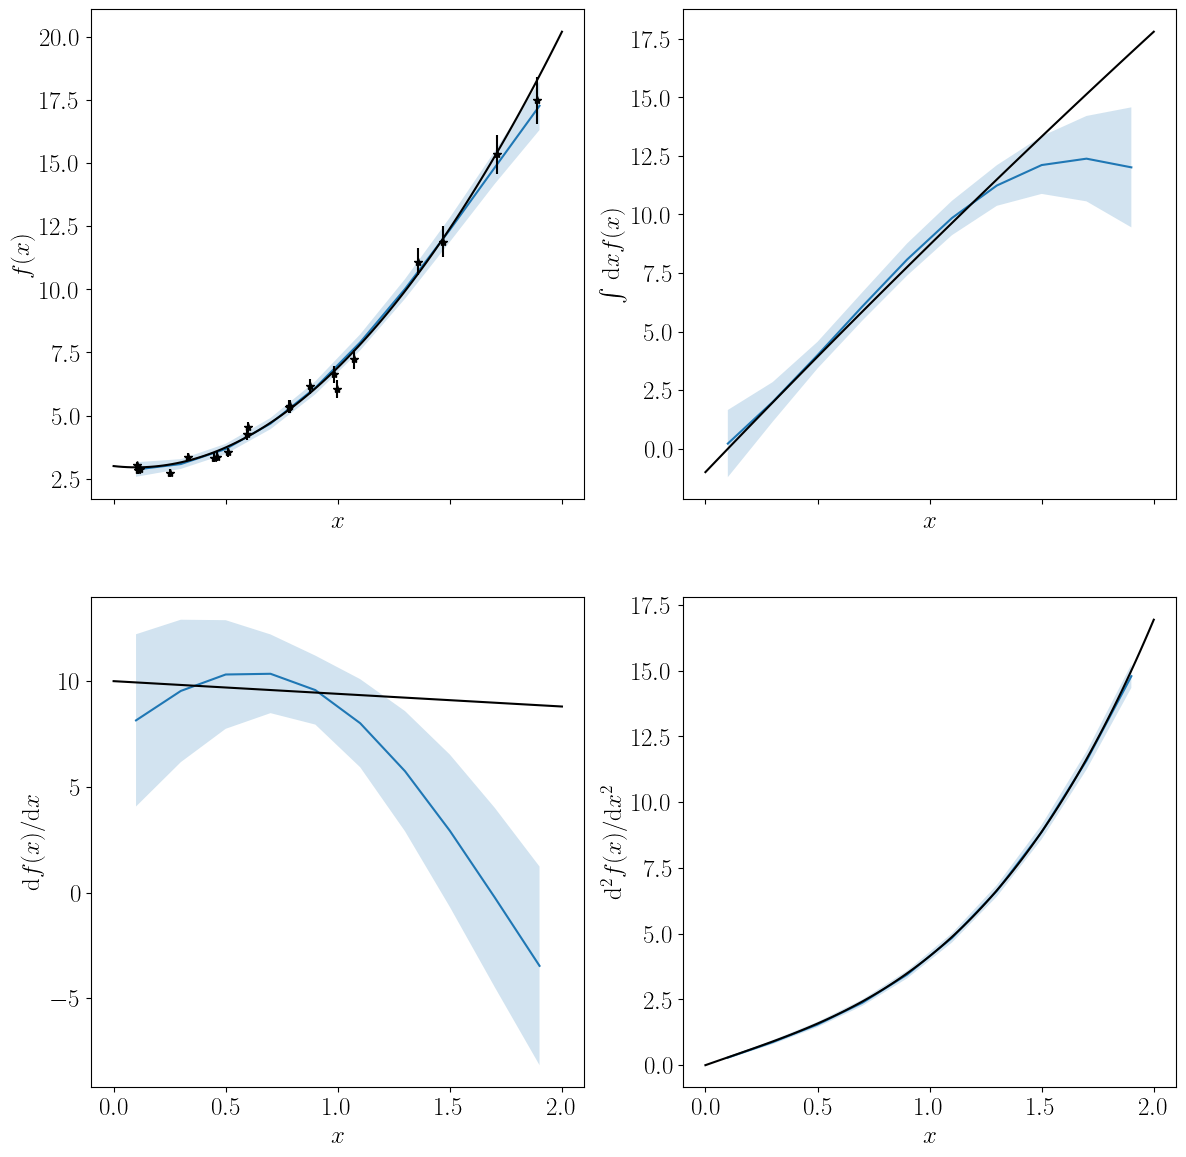

In [5]:
xplot = np.linspace(mindata,maxdata,100)
fig,axes = plt.subplots(nrows=2,ncols=2,sharey=False,sharex=True,figsize=(14,14))

for ind,deriv in enumerate(derivatives):
    if ind == 0:
        i = 0
        j = 0
        label = y_label
    elif ind == 1:
        i = 0
        j = 1
        label = r'$\int$ d'+x_label+''+y_label
    elif ind == 2:
        i = 1
        j = 0
        label = r'd'+y_label+'/d'+x_label
    elif ind == 3:
        i = 1
        j = 1
        label = r'd$^2$'+y_label+'/d'+x_label+r'$^2$'

    axes[i,j].fill_between(x_recon,means[deriv]+means[deriv+'_err'],means[deriv]-means[deriv+'_err'],alpha=0.2)
    axes[i,j].plot(means['x'],means[deriv])
    axes[i,j].plot(xplot,theory[deriv](xplot),color='black')
    if deriv == 'f':
        axes[i,j].errorbar(dataset['x'],dataset[deriv],yerr=dataset[deriv+'_err'],color='black',ls='',marker='*')
    axes[i,j].set_xlabel(x_label)
    axes[i,j].set_ylabel(label)

# Diagnostic tools

Once a reconstruction is complete, it is critical to quantify how well the GP model represents the underlying physics. The Scorer class implements frequentist statistical tests to measure the "tension" between the reconstruction and other references, either observations or theoretical expectations.

## Interpreting the Results
The `Scorer` returns metrics to help interpret the statistical "tension":

* **Reduced $\chi^2$ ($\chi^2_{\nu}$):** Ideally near **1.0**. A value $\gg 1$ suggests the model is a poor fit or the tension is high; a value $\ll 1$ suggests the uncertainties are over-estimated.
* **p-value:** The probability of obtaining a result at least as extreme as the one observed.

### Tension Scale
The `Scorer` provides color-coded reports based on the p-value:
* **$p > 0.05$ (Green):** Good consistency. No significant evidence of tension.
* **$0.01 < p < 0.05$ (Yellow):** Marginal consistency. Potential tension that warrants investigation.
* **$p < 0.01$ (Red):** Poor consistency. Significant tension exists.

### Mode decomposition
The `Scorer` also provides a decomposition in eigenmode of the results, presenting the contribution of each mode to the total $\chi^2$.

This is done by finding the eigenvalus $\lambda_j$ through 

$$\mathbf{C} = \mathbf{U} \mathbf{\Lambda} \mathbf{U}^T$$

and computing the $\chi^2$ for each of the independent modes
$$\chi^2_j = \frac{(\mathbf{U}^T \mathbf{R})_j^2}{\lambda_j}$$

In [6]:
from CoRe.utils.diagnostics import Scorer

scorer = Scorer(means,joint_cov,chatty=True)

In [7]:
GPdiagnostic = pd.DataFrame(columns=['total_chi2','red_chi2','p_value','dof'])

## 1. Scoring Against Theory (Accuracy)

When evaluating how well a reconstruction matches a theoretical curve $y_{th}(x)$, we must decide how to treat the relationship between different points in the reconstruction. The `Scorer` class provides two distinct statistical perspectives.

In [8]:
theory_df = pd.DataFrame({'x': x_recon}|{func: theory[func](x_recon) for func in derivatives})

### A. The Mahalanobis Distance (Joint Scoring)
The Mahalanobis distance measures the separation between the GP mean vector and the theory vector by accounting for the **full joint covariance matrix** ($\Sigma_{GP}$), including all off-diagonal correlations.

$$\chi^2_{joint} = (\vec{\mu}_{GP} - \vec{y}_{th})^T \mathbf{\Sigma}_{GP}^{-1} (\vec{\mu}_{GP} - \vec{y}_{th})$$

* **Global Shape Consistency:** It treats the entire curve as a single physical realization. Because GPs are smooth, a deviation at $x_1$ is physically linked to a deviation at $x_2$ via the kernel.
* **The "Rigidity" Factor:** This metric is highly sensitive to "shape" mismatches. If the theory curve has a slope or feature that the GP kernel cannot replicate, the Mahalanobis distance will increase significantly, even if the error bars are large.
* **When to use:** This is the most mathematically rigorous test for Gaussian Processes.

In [9]:
Mscore = scorer.score_against_theory(theory_df)
GPdiagnostic.loc['Mahalanobis'] = [Mscore[col] for col in GPdiagnostic.columns]


 SCORE REPORT: THEORY CONSISTENCY
Status (Full System): POOR (Significant Tension)
Full Total Chi2:      513265.36
Full Red.  Chi2:      12831.634
Full P-value:         0.0000
Full DOF:             40

Eigenmode Spectrum Breakdown (Sorted by Eigenvalue / Variance Descending):
Mode ID   | Eigenvalue (Var) | Chi2 Contrib  | Percentage | Status  
---------------------------------------------------------------------------
Mode 0    | 8.67e+01         | 2.41          |   0.0%     | ACTIVE
Mode 1    | 2.22e+01         | 3.14          |   0.0%     | ACTIVE
Mode 2    | 1.31e+01         | 3.68          |   0.0%     | ACTIVE
Mode 3    | 2.24e+00         | 0.15          |   0.0%     | ACTIVE
Mode 4    | 6.51e-01         | 1.28          |   0.0%     | ACTIVE
Mode 5    | 4.52e-01         | 0.05          |   0.0%     | ACTIVE
Mode 6    | 1.72e-02         | 10.78         |   0.0%     | ACTIVE
Mode 7    | 3.05e-04         | 1.15          |   0.0%     | ACTIVE
Mode 8    | 3.69e-06         | 15.74     

### B. Pointwise $\chi^2$ Scoring

The pointwise score ignores the correlations (off-diagonal elements) and compares the mean to the theory at each point using only the local variance $\sigma^2_i$.

$$\chi^2_{pointwise} = \sum_{i=1}^{N} \frac{(\mu_i - y_{th, i})^2}{\sigma_i^2}$$

* **Local Accuracy:** This answers the question: "At this specific redshift, how many sigma away is my reconstruction from the theory?"
* **Visual Intuition:** This matches our visual interpretation of plots. If the theory line stays within the $1\sigma$ shaded region, the pointwise $\chi^2$ per degree of freedom will be small.
* **The Risk of Over-optimism:** Because it ignores correlations, pointwise scoring often results in artificially high p-values. It "forgets" that the GP isn't allowed to fluctuate independently at every point, which can make a mediocre fit look statistically acceptable.

In [10]:
Dscore = scorer.score_pointwise(theory_df)
GPdiagnostic.loc['Pointwise'] = [Dscore[col] for col in GPdiagnostic.columns]


 SCORE REPORT: POINTWISE THEORY CONSISTENCY
Status (Full System): GOOD (Consistent)
Full Total Chi2:      27.78
Full Red.  Chi2:      0.694
Full P-value:         0.9280
Full DOF:             40

Pointwise Component Breakdown:
  - f    :     2.48 (  8.9%)
  - d1   :     7.49 ( 27.0%)
  - d2   :    16.88 ( 60.8%)
  - int  :     0.93 (  3.3%)



## 2. Scoring Against Data (Consistency)
This method compares the reconstruction against external data points that were not used in the training, or checks the self-consistency of the fit against a secondary probe.

### The Logic
Unlike the theory score, we must account for the uncertainties in **both** the reconstruction and the data. The total covariance is the sum of the two:

$$\chi^2_{data} = (\vec{y}_{data} - \vec{\mu}_{GP})^T \left[ \mathbf{\Sigma}_{GP} + \mathbf{\Sigma}_{data} \right]^{-1} (\vec{y}_{data} - \vec{\mu}_{GP})$$

The `Scorer` automatically handles the alignment of coordinates, extracting the GP's predicted values and covariance at the specific $x$-locations where the data points exist.

In [11]:
datasets = [{'type': 'f',
             'df': dataset,
             'cov': covmat}]

In [12]:
data_score = scorer.score_against_data(datasets)
GPdiagnostic.loc['Data'] = [data_score[col] for col in GPdiagnostic.columns]


 SCORE REPORT: EXTERNAL DATA VALIDATION
Status (Full System): GOOD (Consistent)
Full Total Chi2:      7.84
Full Red.  Chi2:      0.392
Full P-value:         0.9929
Full DOF:             20

Eigenmode Spectrum Breakdown (Sorted by Eigenvalue / Variance Descending):
Mode ID   | Eigenvalue (Var) | Chi2 Contrib  | Percentage | Status  
---------------------------------------------------------------------------
Mode 0    | 3.18e+00         | 0.05          |   0.6%     | ACTIVE
Mode 1    | 1.75e+00         | 0.08          |   1.0%     | ACTIVE
Mode 2    | 1.40e+00         | 0.00          |   0.0%     | ACTIVE
Mode 3    | 1.15e+00         | 1.20          |  15.3%     | ACTIVE
Mode 4    | 9.64e-01         | 0.02          |   0.3%     | ACTIVE
Mode 5    | 7.63e-01         | 1.49          |  19.0%     | ACTIVE
Mode 6    | 6.82e-01         | 0.33          |   4.3%     | ACTIVE
Mode 7    | 6.60e-01         | 0.08          |   1.0%     | ACTIVE
Mode 8    | 6.10e-01         | 0.00          |   0.0%

In [13]:
GPdiagnostic

,total_chi2,red_chi2,p_value,dof
Mahalanobis,513265.356928,12831.633923,0.000000,40.0
Pointwise,27.775722,0.694393,0.927985,40.0
Data,7.842431,0.392122,0.992860,20.0


## Eigenmodes truncation

When assessing the joint consistency of cosmological reconstructions across a function and its derivatives/integrals (e.g., $f, d_1, d_2, \text{int}$), the full covariance matrix $\mathbf{C}$ becomes dense and highly correlated. This can lead to unphysical diagnostic results if not treated properly. The implementation of **Eigenmode Truncation** provides a way to separate physical signals from numerical noise.

---

### 1. The Problem of Small Eigenvalues (The Noise Floor)

In a joint fit, the total $\chi^2$ is defined as:
$$\chi^2 = \mathbf{R}^T \mathbf{C}^{-1} \mathbf{R}$$
where $\mathbf{R} = \mathbf{y}_{\text{recon}} - \mathbf{y}_{\text{theory}}$ is the vector of residuals. 

Because operations like numerical differentiation link nearby points rigidly, $\mathbf{C}$ possesses directions of extremely tight constraint. When performing an eigen-decomposition ($\mathbf{C} = \mathbf{U} \mathbf{\Lambda} \mathbf{U}^T$), these directions correspond to exceptionally small eigenvalues ($\lambda_j \ll 1$). 

Since the $\chi^2$ can be rewritten in the orthogonal eigenbasis as:
$$\chi^2 = \sum_{j=1}^{N} \frac{(\mathbf{U}^T \mathbf{R})_j^2}{\lambda_j}$$

Any minute numerical truncation error, sub-percent systematic shift, or slight phase mismatch in the theoretical model gets amplified by $1/\lambda_j$. Consequently, a poor global $p$-value is frequently driven not by a true macroscopic physical misfit, but by uninformative, sub-grid noise modes near the machine precision limit.

---

### 2. Subspace Truncation via the Cutoff Factor $F$

To isolate the meaningful physical subspace, we introduce a filtering threshold factor, $F$. We evaluate the maximum eigenvalue $\lambda_{\max}$ (which represents the mode with the highest variance/physical scale) and define a cutoff threshold:

$$\text{Threshold} = \frac{\lambda_{\max}}{F}$$

We sort the eigenvalues in descending order ($\lambda_1 \ge \lambda_2 \ge \dots \ge \lambda_N$). An eigenmode $j$ is preserved if and only if:
$$\lambda_j \ge \lambda_1\,F$$

Modes that fail this condition are discarded, removing components that bring virtually zero physical information to the macroscopic reconstruction.

The value of $F$ can be passed to the `Scorer` class by setting the optional argument `eigen_trunc_factor`.

---

### 3. Rigorous Subspace Statistics

Because the transformation matrix $\mathbf{U}$ is orthogonal, the components of the transformed residual vector $\mathbf{y}' = \mathbf{U}^T \mathbf{R}$ are **completely statistically independent**. Each transformed component behaves as a univariate Gaussian variable with variance $\lambda_j$:
$$y'_j \sim \mathcal{N}(0, \lambda_j)$$

This independence guarantees that dropping a mode maps directly to a clean linear projection onto a lower-dimensional Gaussian hyperspace.

#### Truncated $\chi^2$
Let $\mathcal{K}$ be the set of $k$ indices that pass the threshold criterion. The truncated $\chi^2$ is safely computed as the sum over this active subspace:
$$\chi^2_{\text{trunc}} = \sum_{j \in \mathcal{K}} \frac{(y'_j)^2}{\lambda_j}$$

#### Truncated Degrees of Freedom (DOF)
Because each eigenmode represents a decoupled, orthogonal direction of variation, discarding a mode removes exactly one independent degree of freedom. Therefore, the degrees of freedom for the truncated system is exactly equal to the number of surviving modes:
$$N_{\rm DOF}^{\rm trunc} = k = |\mathcal{K}|$$

#### Truncated Reduced $\chi^2$
The truncated reduced $\chi^2$ rescales the goodness-of-fit statistic back to the dimensionality of the surviving physical subspace:
$$\chi^2_{\text{red, trunc}} = \frac{\chi^2_{\text{trunc}}}{k}$$

#### Truncated $p$-value
Since the underlying variables are independent Gaussians, $\chi^2_{\text{trunc}}$ strictly follows a standard Chi-squared distribution with $k$ degrees of freedom ($X \sim \chi^2_k$). The probability of obtaining a fit statistic at least this extreme by chance is given by the survival function:
$$p\text{-value}_{\text{trunc}} = 1 - {\rm CDF}_{\chi^2_k}(\chi^2_{\text{trunc}})$$
where ${\rm CDF}_{\chi^2_k}$ is the Cumulative Distribution Function (CDF) of the $\chi^2$ distribution with $k$ degrees of freedom.

---

### Diagnostic Interpretation

* **Full System $p$-value is bad, but Truncated $p$-value is good:** The macro-features of the physical model are fully compatible with the reconstruction. The tension is entirely driven by high-frequency numerical artifacts or derivative stencil limits. 
* **Both Full and Truncated $p$-values are bad:** There is a genuine physical discrepancy between the theoretical model and the reconstruction on large, highly informative physical scales.

In [14]:
GPdiagnostic = pd.DataFrame(columns=['total_chi2','red_chi2','p_value','dof',
                                     'truncated_chi2','truncated_red_chi2','truncated_p_value','truncated_dof'])

In [15]:
scorer = Scorer(means,joint_cov,chatty=True,eigen_trunc_factor=1.e-5)

In [16]:
Mscore = scorer.score_against_theory(theory_df)
GPdiagnostic.loc['Mahalanobis'] = [Mscore[col] for col in GPdiagnostic.columns]


 SCORE REPORT: THEORY CONSISTENCY
Status (Full System): POOR (Significant Tension)
Full Total Chi2:      513265.36
Full Red.  Chi2:      12831.634
Full P-value:         0.0000
Full DOF:             40
------------------------------------------------------------
Truncated Subspace Metrics (Cutoff Factor F = 1e-05):
Truncated Chi2:       21.49
Truncated Red. Chi2:  3.070
Truncated P-value:    0.0031
Truncated DOF:        7 (Dropped 33 noisy modes)

Eigenmode Spectrum Breakdown (Sorted by Eigenvalue / Variance Descending):
Mode ID   | Eigenvalue (Var) | Chi2 Contrib  | Percentage | Status  
---------------------------------------------------------------------------
Mode 0    | 8.67e+01         | 2.41          |   0.0%     | KEPT
Mode 1    | 2.22e+01         | 3.14          |   0.0%     | KEPT
Mode 2    | 1.31e+01         | 3.68          |   0.0%     | KEPT
Mode 3    | 2.24e+00         | 0.15          |   0.0%     | KEPT
Mode 4    | 6.51e-01         | 1.28          |   0.0%     | KEPT
Mod

In [17]:
data_score = scorer.score_against_data(datasets)
GPdiagnostic.loc['Data'] = [data_score[col] for col in GPdiagnostic.columns]


 SCORE REPORT: EXTERNAL DATA VALIDATION
Status (Full System): GOOD (Consistent)
Full Total Chi2:      7.84
Full Red.  Chi2:      0.392
Full P-value:         0.9929
Full DOF:             20
------------------------------------------------------------
Truncated Subspace Metrics (Cutoff Factor F = 1e-05):
Truncated Chi2:       7.84
Truncated Red. Chi2:  0.392
Truncated P-value:    0.9929
Truncated DOF:        20 (Dropped 0 noisy modes)

Eigenmode Spectrum Breakdown (Sorted by Eigenvalue / Variance Descending):
Mode ID   | Eigenvalue (Var) | Chi2 Contrib  | Percentage | Status  
---------------------------------------------------------------------------
Mode 0    | 3.18e+00         | 0.05          |   0.6%     | KEPT
Mode 1    | 1.75e+00         | 0.08          |   1.0%     | KEPT
Mode 2    | 1.40e+00         | 0.00          |   0.0%     | KEPT
Mode 3    | 1.15e+00         | 1.20          |  15.3%     | KEPT
Mode 4    | 9.64e-01         | 0.02          |   0.3%     | KEPT
Mode 5    | 7.63

In [18]:
GPdiagnostic

,total_chi2,red_chi2,p_value,dof,truncated_chi2,truncated_red_chi2,truncated_p_value,truncated_dof
Mahalanobis,513265.356928,12831.633923,0.00000,40.0,21.489416,3.069917,0.003109,7.0
Data,7.842431,0.392122,0.99286,20.0,7.842431,0.392122,0.992860,20.0


# Reconstruction grid

Here we use the scorer module to visualize the dependence of a Gaussian Process on different settings, running on a grid of several choice combinations.

**TO BE FINISHED!!!**

## Settings

In [19]:
data_range  = [0.,2.]
recon_range = [0.1,1.8]


free_settings = {'Nrecon': [5,10,15],
                 'order': [3],#,4,5],
                 'Ndata': [25,50,100],
                 'error': [1,5,10.],
                 'logtruncation': [-7,-5,-3],
                 'kernel': ['RBF']}


prior_sampling = 1

## Run grid for MAP

In [20]:
import math
import subprocess
dfs = []

keys = free_settings.keys()

locind = 0
total  = math.prod(len(v) for v in free_settings.values())*prior_sampling
for values in product(*free_settings.values()):

    print('')
    loc_dict = dict(zip(keys, values))

    x_recon = np.linspace(recon_range[0],recon_range[1],loc_dict['Nrecon'])

    tini = time()
    df = pd.DataFrame(loc_dict,index=[0])
    
    params = deepcopy(fiducial)
    theory = get_theory(list(params.values()))
    dataset,covmat = create_data(theory,loc_dict['Ndata'],data_range[0],data_range[1],loc_dict['error'],seed=42)

    means,joint_cov,lml = get_GP(dataset,covmat,loc_dict['kernel'],x_recon,'MAP')
    
    scorer = Scorer(means,joint_cov,chatty=False,eigen_trunc_factor=10**loc_dict['logtruncation'])
    
    theory_df = pd.DataFrame({'x': x_recon}|{func: theory[func](x_recon) for func in ['f','d1','d2','int']})
    res         = scorer.score_against_theory(theory_df)
    df['M-score']   = res['truncated_p_value']
    
    res = scorer.score_pointwise(theory_df)
    df['D-score'] = res['p_value']
    
    datasets = [{'type': 'f',
                 'df': dataset,
                 'cov': covmat}]
    res = scorer.score_against_data(datasets)
    df['Data score'] = res['truncated_p_value']
    df['Method'] = 'MAP'
    
    dfs.append(df)
        
    print('Test {} of {} done in {:.2f} s'.format(locind+1,total,time()-tini))

    locind += 1

results_map = pd.concat(dfs,ignore_index=True)


Test 1 of 81 done in 15.87 s

Test 2 of 81 done in 2.52 s

Test 3 of 81 done in 2.56 s

Test 4 of 81 done in 2.75 s

Test 5 of 81 done in 2.51 s

Test 6 of 81 done in 2.44 s

Test 7 of 81 done in 2.29 s

Test 8 of 81 done in 2.67 s

Test 9 of 81 done in 2.85 s

Test 10 of 81 done in 5.60 s

Test 11 of 81 done in 2.77 s

Test 12 of 81 done in 2.63 s

Test 13 of 81 done in 3.45 s

Test 14 of 81 done in 2.67 s

Test 15 of 81 done in 2.69 s

Test 16 of 81 done in 2.84 s

Test 17 of 81 done in 3.04 s

Test 18 of 81 done in 2.67 s

Test 19 of 81 done in 5.51 s

Test 20 of 81 done in 2.98 s

Test 21 of 81 done in 2.52 s

Test 22 of 81 done in 2.53 s

Test 23 of 81 done in 2.55 s

Test 24 of 81 done in 2.58 s

Test 25 of 81 done in 2.44 s

Test 26 of 81 done in 2.65 s

Test 27 of 81 done in 2.55 s

Test 28 of 81 done in 4.79 s

Test 29 of 81 done in 2.49 s

Test 30 of 81 done in 2.51 s

Test 31 of 81 done in 2.76 s

Test 32 of 81 done in 2.41 s

Test 33 of 81 done in 2.65 s

Test 34 of 81 don

## Run grid for Bayesian

In [21]:
import math
import subprocess
dfs = []

keys = free_settings.keys()

locind = 0
total  = math.prod(len(v) for v in free_settings.values())*prior_sampling
for values in product(*free_settings.values()):

    print('')
    loc_dict = dict(zip(keys, values))

    x_recon = np.linspace(recon_range[0],recon_range[1],loc_dict['Nrecon'])

    tini = time()
    df = pd.DataFrame(loc_dict,index=[0])
    
    params = deepcopy(fiducial)
    theory = get_theory(list(params.values()))
    dataset,covmat = create_data(theory,loc_dict['Ndata'],data_range[0],data_range[1],loc_dict['error'],seed=42)

    dataset.to_csv('data/temp_data.txt',sep='\t',header=True,index=False)
    covmat.to_csv('data/temp_covmat.txt',sep='\t',header=True,index=True)

    temp_yaml = {'outroot': 'results/temp',
                 'chatty': True,
                 'want_score': False,
                 'datasets': {'fx': {'data_path': 'data/temp_data.txt',
                                     'covmat_path': 'data/temp_covmat.txt',
                                     'fiducial_path': None}},
                 'reconstruction_settings': {'name': 'GaussianProcess',
                                             'N': loc_dict['Nrecon'],
                                             'xmin': recon_range[0],
                                             'xmax': recon_range[1],
                                             'kernel': loc_dict['kernel'],
                                             'pars_selection': 'BAYESIAN'}}
  

    with open('running_settings/temp.yaml', 'w') as file:
        yaml.dump(temp_yaml,file,default_flow_style=False, sort_keys=False)

    try:
        result = subprocess.run([sys.executable, "runner.py", "running_settings/temp.yaml"],
                                capture_output=True,text=True,check=True)
    
    except subprocess.CalledProcessError as e:
        print(f"Error executing runner.py:\n{e.stderr}")
        break

    means     = pd.read_csv('results/temp_fx_means.txt',sep='\t',header=0)
    joint_cov = pd.read_csv('results/temp_fx_covmat.txt',sep='\s+',header=0)
    joint_cov.index = joint_cov.columns

    os.remove('running_settings/temp.yaml')
    os.remove('data/temp_data.txt')
    os.remove('data/temp_covmat.txt')
    os.remove('results/temp_fx_means.txt')
    os.remove('results/temp_fx_covmat.txt')
    
    scorer = Scorer(means,joint_cov,chatty=False,eigen_trunc_factor=10**loc_dict['logtruncation'])
    
    theory_df = pd.DataFrame({'x': x_recon}|{func: theory[func](x_recon) for func in ['f','d1','d2','int']})
    res         = scorer.score_against_theory(theory_df)
    df['M-score']   = res['truncated_p_value']
    
    res = scorer.score_pointwise(theory_df)
    df['D-score'] = res['p_value']
    
    datasets = [{'type': 'f',
                 'df': dataset,
                 'cov': covmat}]
    res = scorer.score_against_data(datasets)
    df['Data score'] = res['truncated_p_value']
    df['Method'] = 'BAYESIAN'
    
    dfs.append(df)
        
    print('Test {} of {} done in {:.2f} s'.format(locind+1,total,time()-tini))

    locind += 1

results_bayesian = pd.concat(dfs,ignore_index=True)


Test 1 of 81 done in 104.08 s

Test 2 of 81 done in 109.29 s

Test 3 of 81 done in 73.59 s

Test 4 of 81 done in 93.01 s

Test 5 of 81 done in 95.78 s

Test 6 of 81 done in 52.07 s

Test 7 of 81 done in 46.25 s

Test 8 of 81 done in 52.87 s

Test 9 of 81 done in 46.79 s

Test 10 of 81 done in 44.65 s

Test 11 of 81 done in 44.03 s

Test 12 of 81 done in 49.60 s

Test 13 of 81 done in 50.74 s

Test 14 of 81 done in 44.31 s

Test 15 of 81 done in 44.20 s

Test 16 of 81 done in 89.06 s

Test 17 of 81 done in 93.87 s

Test 18 of 81 done in 48.65 s

Test 19 of 81 done in 62.58 s

Test 20 of 81 done in 65.35 s

Test 21 of 81 done in 55.02 s

Test 22 of 81 done in 55.87 s

Test 23 of 81 done in 55.35 s

Test 24 of 81 done in 47.96 s

Test 25 of 81 done in 51.07 s

Test 26 of 81 done in 54.24 s

Test 27 of 81 done in 52.24 s

Test 28 of 81 done in 49.63 s

Test 29 of 81 done in 53.24 s

Test 30 of 81 done in 60.89 s

Test 31 of 81 done in 82.71 s

Test 32 of 81 done in 47.05 s

Test 33 of 81 

In [22]:
results = pd.concat([results_map,results_bayesian],ignore_index=True)

## Plotting results

In [23]:
parameters = ['Nrecon','Ndata','error','logtruncation']

### MAP results

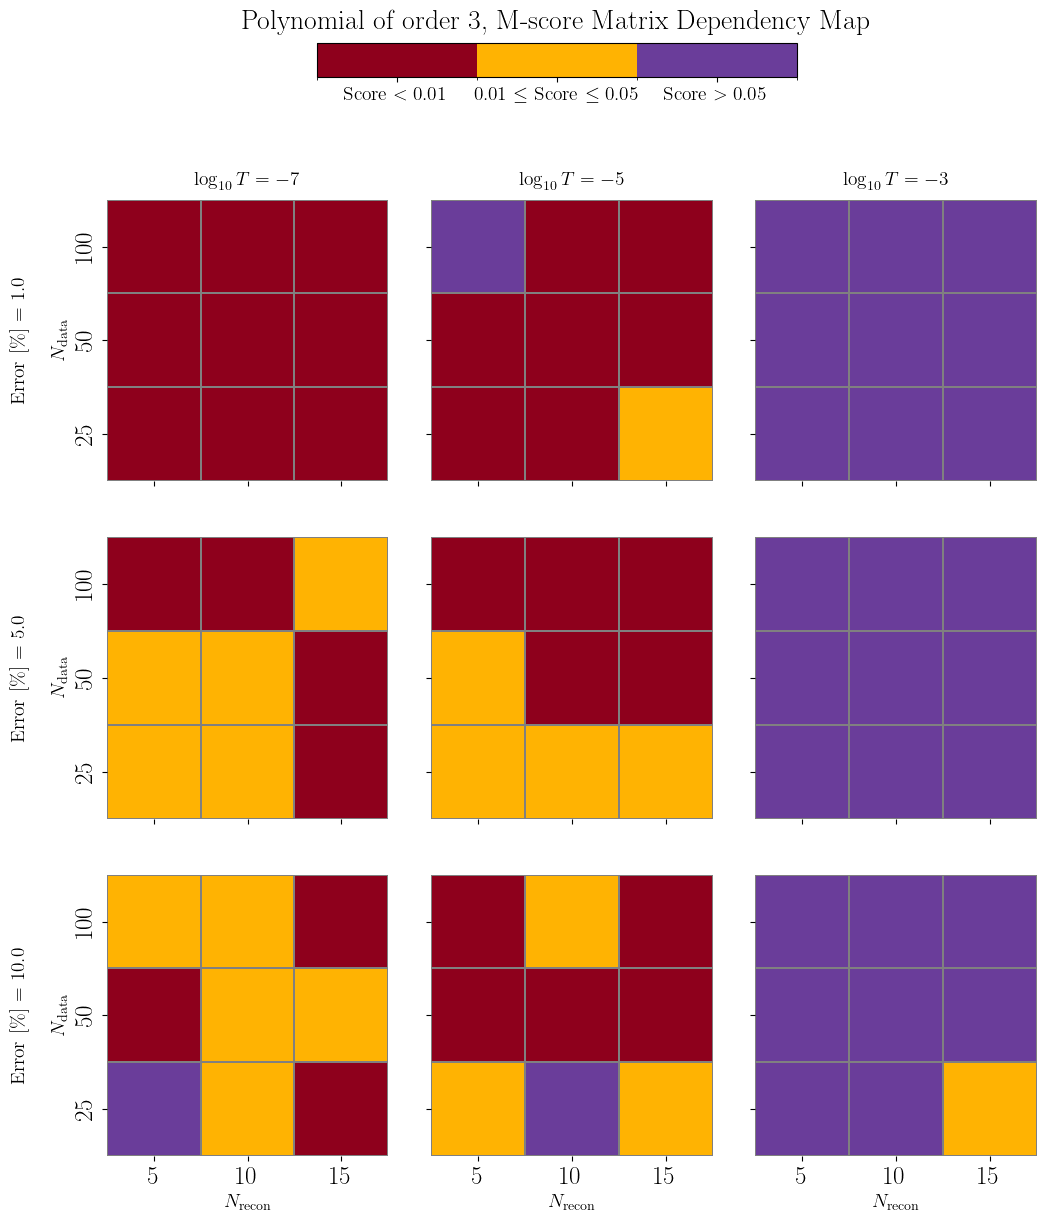

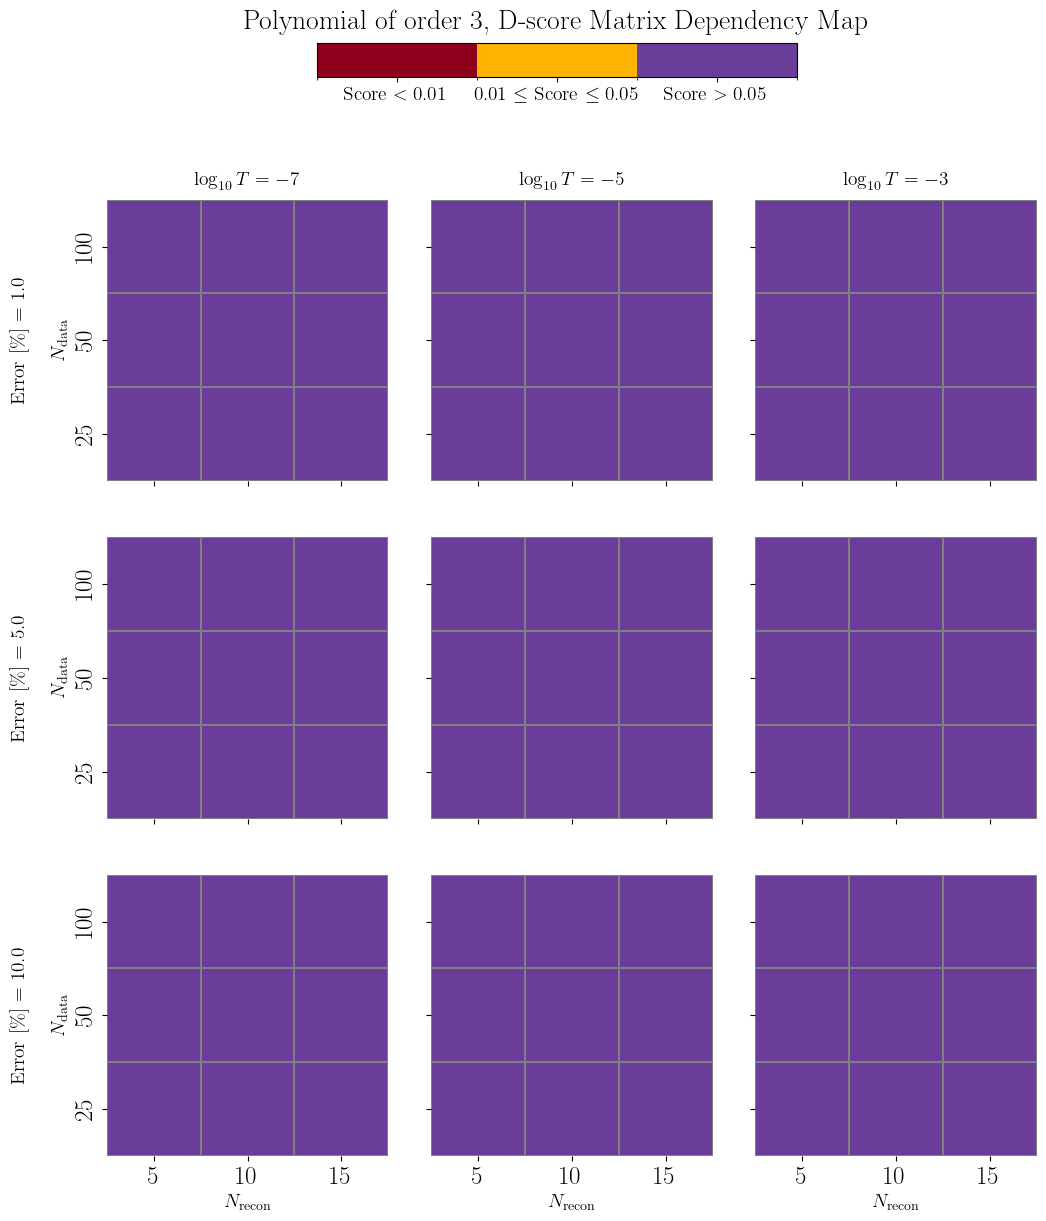

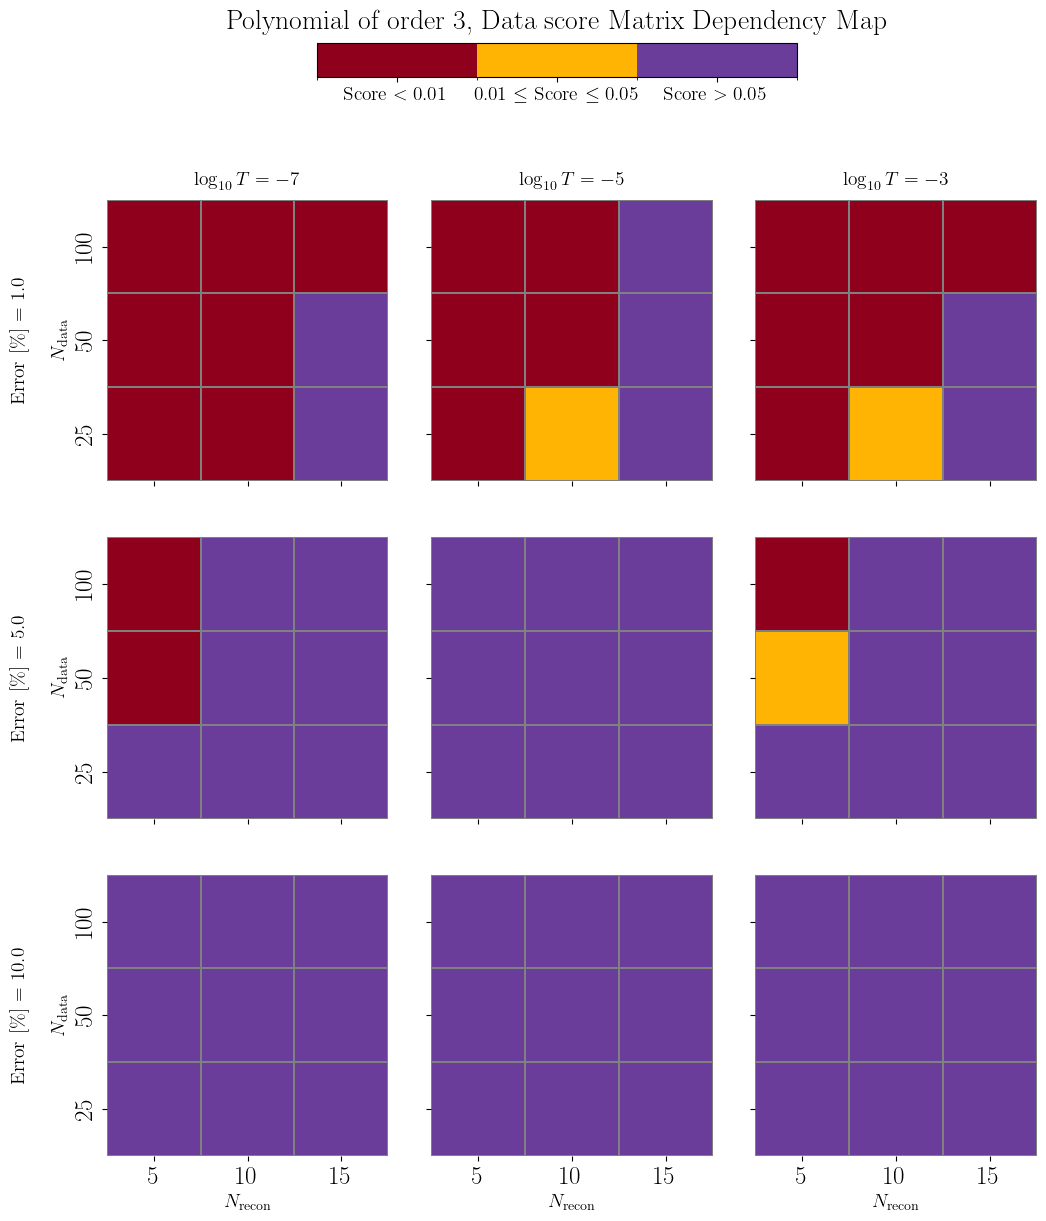

In [25]:
method_df = results[(results['Method']=='MAP') & (results['kernel']=='RBF')]
for order in results['order'].unique():
    ord_df = method_df[method_df['order']==3]
    for score_col in ['M-score','D-score','Data score']:
        cols_to_keep = [score_col]+parameters
        df = ord_df.drop(columns=[col for col in ord_df.columns if col not in cols_to_keep])

        my_colors  = [red,yellow,"#6a3d9a"]  # Red, Yellow, Purple
        boundaries = [0.0, 0.01, 0.05, 1.0]
        
        cmap = mcolors.ListedColormap(my_colors)
        norm = mcolors.BoundaryNorm(boundaries, cmap.N)
        # --- 1. Identify unique sorted values for the outer grid parameters ---
        unique_c = sorted(df['error'].unique())
        unique_d = sorted(df['logtruncation'].unique())
        
        nrows = len(unique_c)
        ncols = len(unique_d)

        # --- 2. Initialize the subplot structure ---
        # We allocate an extra narrow column on the far right for a unified colorbar
        fig, axes = plt.subplots(nrows=nrows,ncols=ncols,figsize=(4 * ncols, 4 * nrows+1.5),
                                 sharex="col",sharey="row")

        if nrows == 1 and ncols == 1:
            axes = np.array([[axes]])
        elif nrows == 1:
            axes = axes[np.newaxis, :]
        elif ncols == 1:
            axes = axes[:, np.newaxis]

        # --- 3. Loop through the grid and build the heatmaps ---
        for row_idx, c_val in enumerate(unique_c):
            for col_idx, d_val in enumerate(unique_d):
        
                ax = axes[row_idx, col_idx]
        
                # Filter the dataframe for the specific combination of c and d
                sub_df = df[(df['error'] == c_val) & (df['logtruncation'] == d_val)]
        
                if not sub_df.empty:
                    matrix_df = sub_df.pivot(index='Ndata',columns='Nrecon',values=score_col)
        
                    # Sort index and columns explicitly so axes match across all subplots
                    matrix_df = matrix_df.sort_index(ascending=False).sort_index(axis=1)
        
                    sb.heatmap(matrix_df,ax=ax,cmap=cmap,norm=norm,cbar=False,square=True,linewidths=0.2,linecolor="gray")
                else:
                    # Handle empty combinations gracefully
                    ax.text(0.5,0.5,"No Data",ha="center",va="center",transform=ax.transAxes,)
                    ax.set_facecolor("#f0f0f0")
        
                # --- 4. Handle Subplot Labels ---
                # Add labels designating the outer grid positions (only on edges to prevent clutter)
                if col_idx == 0:
                    ax.set_ylabel(r"Error [\%] = " + f"{c_val}" + "\n\n" + r"$N_{\rm data}$", fontsize=14)
                else:
                    ax.set_ylabel("")  # Hidden by sharey, but clears out automatic labels
        
                if row_idx == 0:
                    ax.set_title(f"$\log_{{10}}{{T}} = {d_val}$", fontsize=14, pad=10)
        
                if row_idx == nrows - 1:
                    ax.set_xlabel(r'$N_{\rm recon}$', fontsize=14)
                else:
                    ax.set_xlabel("")
        
        fig.suptitle(f"Polynomial of order {order}, {score_col} Matrix Dependency Map",fontsize=20,fontweight="bold",y=0.95)
        plt.subplots_adjust(top=0.83, bottom=0.08, hspace=0., wspace=0.15)

        # Create a custom horizontal axis directly below the suptitle
        # Coordinates format: [left_x, bottom_y, width, height] as fractions of the figure
        cbar_ax = fig.add_axes([0.3, 0.9, 0.4, 0.025])
        
        # Create a structural mappable link
        mappable = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
        
        # Build the unified colorbar
        cbar = fig.colorbar(mappable,cax=cbar_ax,orientation="horizontal",spacing="uniform",ticks=[0.005, 0.03, 0.525],)
        
        # Center labels cleanly beneath each discrete colored block
        cbar.ax.set_xticklabels([r"Score $< 0.01$", r"$0.01 \leq$ Score $\leq 0.05$", r"Score $> 0.05$"],
                                fontsize=14,fontweight="bold")
        cbar.ax.xaxis.set_ticks_position("bottom")

## Bayesian results

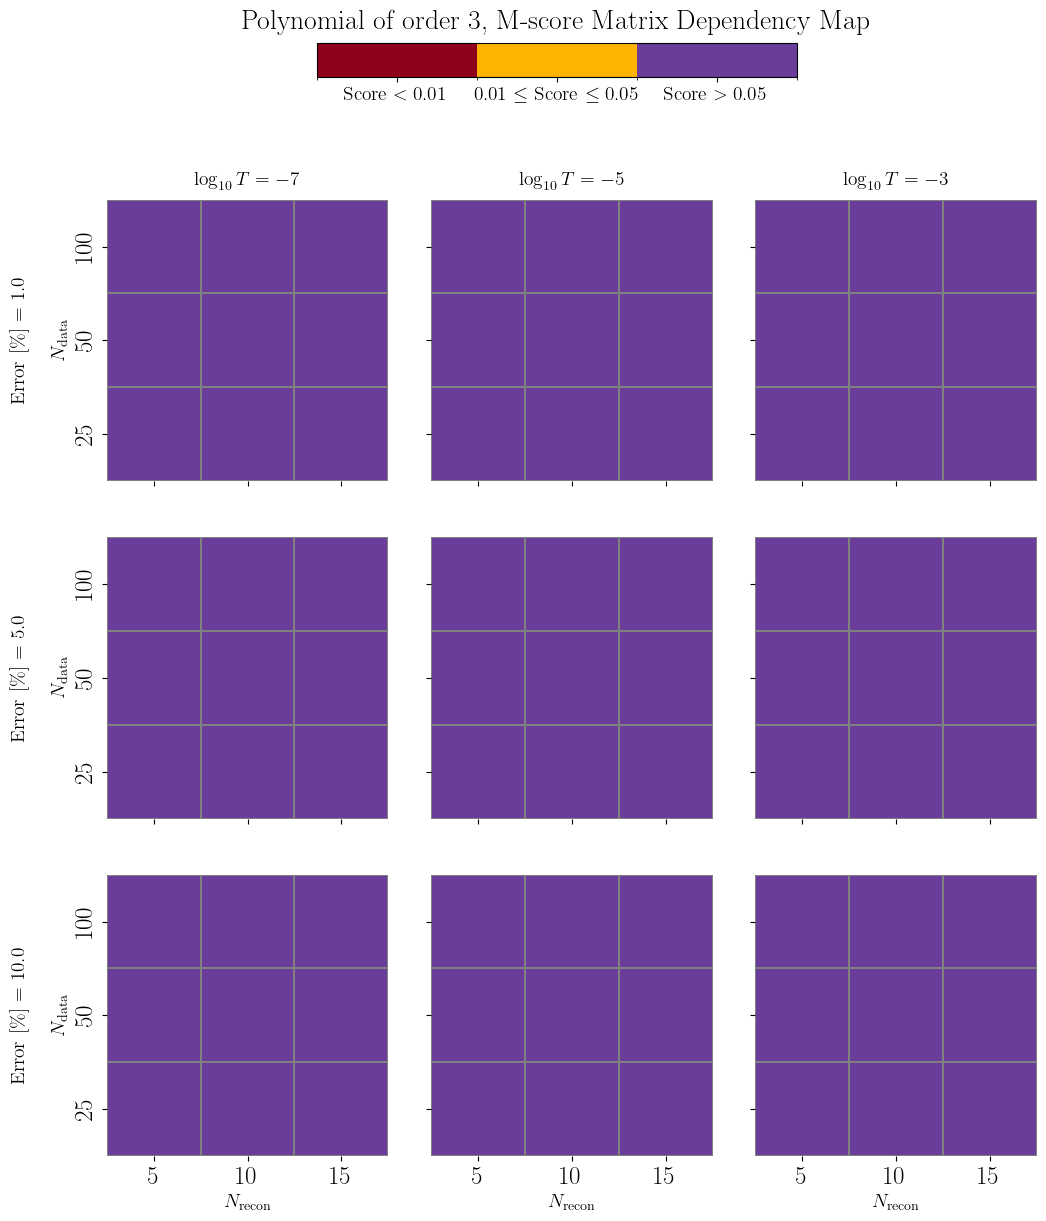

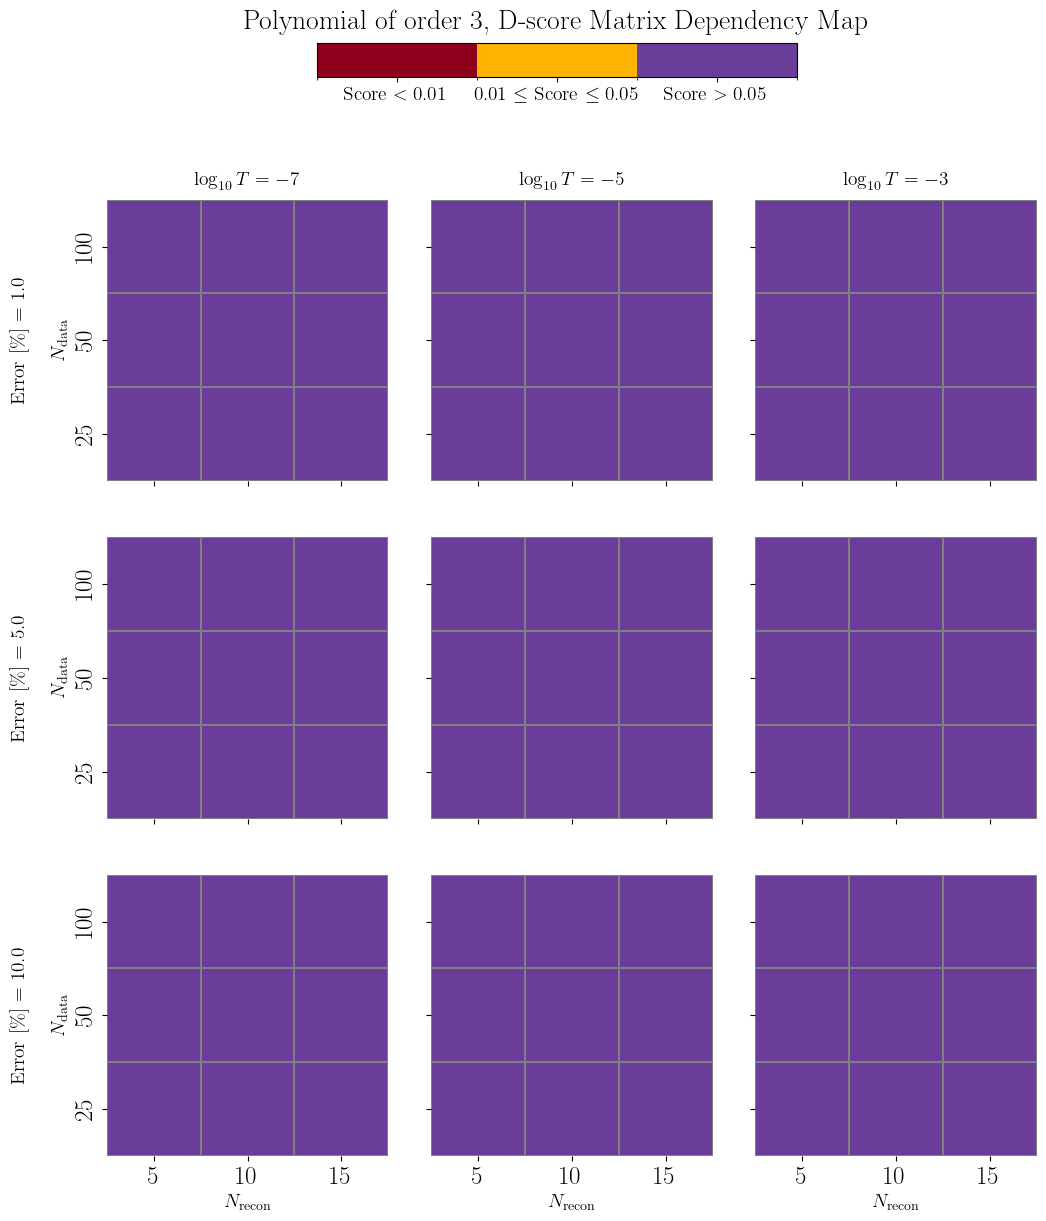

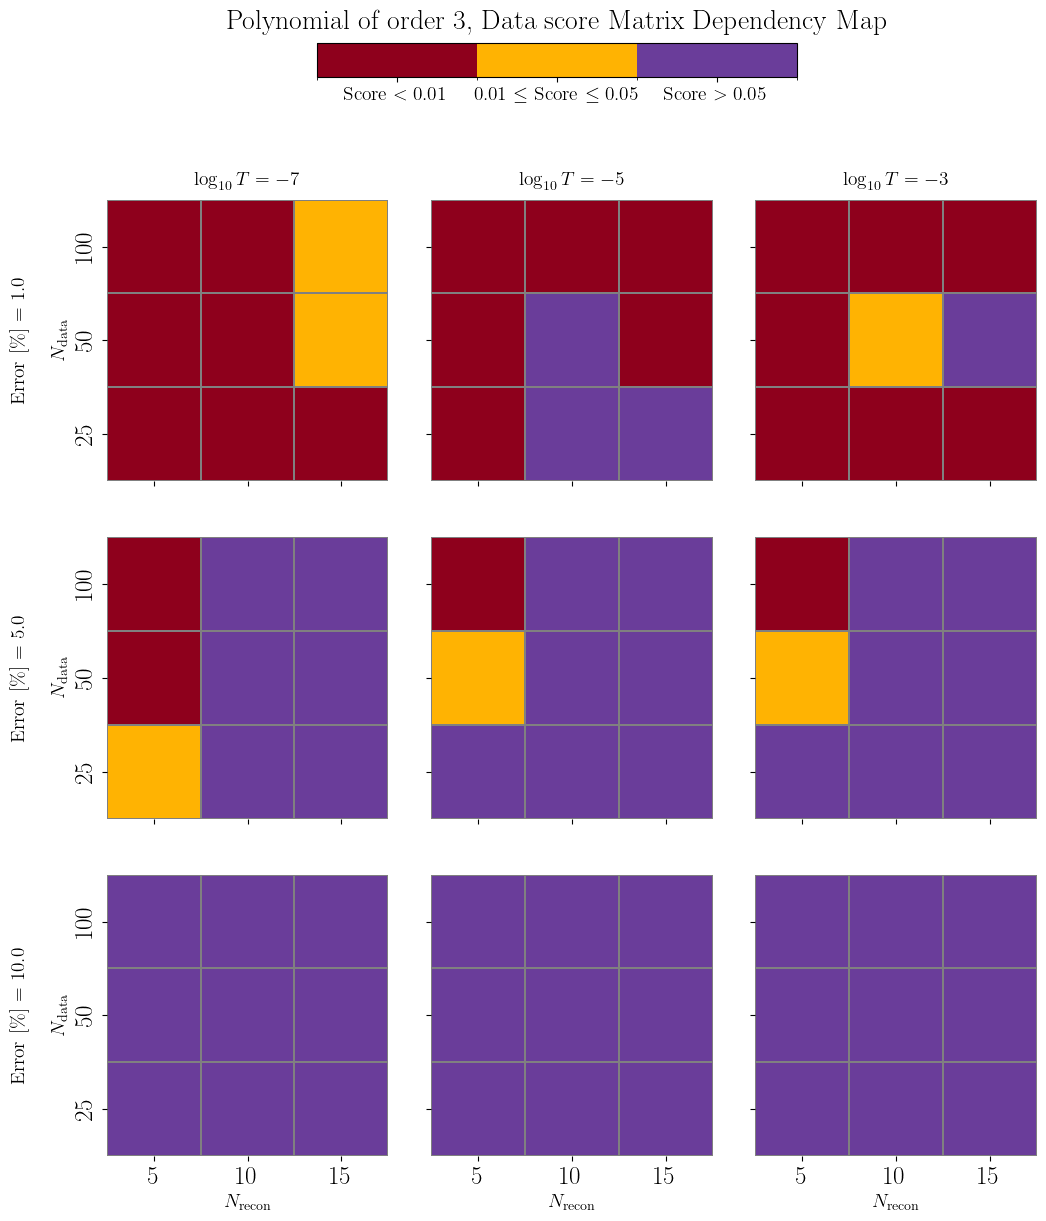

In [26]:
method_df = results[(results['Method']=='BAYESIAN') & (results['kernel']=='RBF')]
if len(method_df) == 0:
    raise RuntimeError('No Bayesian results')
    
for order in results['order'].unique():
    ord_df = method_df[method_df['order']==3]
    for score_col in ['M-score','D-score','Data score']:
        cols_to_keep = [score_col]+parameters
        df = ord_df.drop(columns=[col for col in ord_df.columns if col not in cols_to_keep])

        my_colors  = [red,yellow,"#6a3d9a"]  # Red, Yellow, Purple
        boundaries = [0.0, 0.01, 0.05, 1.0]
        
        cmap = mcolors.ListedColormap(my_colors)
        norm = mcolors.BoundaryNorm(boundaries, cmap.N)
        # --- 1. Identify unique sorted values for the outer grid parameters ---
        unique_c = sorted(df['error'].unique())
        unique_d = sorted(df['logtruncation'].unique())
        
        nrows = len(unique_c)
        ncols = len(unique_d)

        # --- 2. Initialize the subplot structure ---
        # We allocate an extra narrow column on the far right for a unified colorbar
        fig, axes = plt.subplots(nrows=nrows,ncols=ncols,figsize=(4 * ncols, 4 * nrows+1.5),
                                 sharex="col",sharey="row")

        if nrows == 1 and ncols == 1:
            axes = np.array([[axes]])
        elif nrows == 1:
            axes = axes[np.newaxis, :]
        elif ncols == 1:
            axes = axes[:, np.newaxis]

        # --- 3. Loop through the grid and build the heatmaps ---
        for row_idx, c_val in enumerate(unique_c):
            for col_idx, d_val in enumerate(unique_d):
        
                ax = axes[row_idx, col_idx]
        
                # Filter the dataframe for the specific combination of c and d
                sub_df = df[(df['error'] == c_val) & (df['logtruncation'] == d_val)]
        
                if not sub_df.empty:
                    matrix_df = sub_df.pivot(index='Ndata',columns='Nrecon',values=score_col)
        
                    # Sort index and columns explicitly so axes match across all subplots
                    matrix_df = matrix_df.sort_index(ascending=False).sort_index(axis=1)
        
                    sb.heatmap(matrix_df,ax=ax,cmap=cmap,norm=norm,cbar=False,square=True,linewidths=0.2,linecolor="gray")
                else:
                    # Handle empty combinations gracefully
                    ax.text(0.5,0.5,"No Data",ha="center",va="center",transform=ax.transAxes,)
                    ax.set_facecolor("#f0f0f0")
        
                # --- 4. Handle Subplot Labels ---
                # Add labels designating the outer grid positions (only on edges to prevent clutter)
                if col_idx == 0:
                    ax.set_ylabel(r"Error [\%] = " + f"{c_val}" + "\n\n" + r"$N_{\rm data}$", fontsize=14)
                else:
                    ax.set_ylabel("")  # Hidden by sharey, but clears out automatic labels
        
                if row_idx == 0:
                    ax.set_title(f"$\log_{{10}}{{T}} = {d_val}$", fontsize=14, pad=10)
        
                if row_idx == nrows - 1:
                    ax.set_xlabel(r'$N_{\rm recon}$', fontsize=14)
                else:
                    ax.set_xlabel("")
        
        fig.suptitle(f"Polynomial of order {order}, {score_col} Matrix Dependency Map",fontsize=20,fontweight="bold",y=0.95)
        plt.subplots_adjust(top=0.83, bottom=0.08, hspace=0., wspace=0.15)

        # Create a custom horizontal axis directly below the suptitle
        # Coordinates format: [left_x, bottom_y, width, height] as fractions of the figure
        cbar_ax = fig.add_axes([0.3, 0.9, 0.4, 0.025])
        
        # Create a structural mappable link
        mappable = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
        
        # Build the unified colorbar
        cbar = fig.colorbar(mappable,cax=cbar_ax,orientation="horizontal",spacing="uniform",ticks=[0.005, 0.03, 0.525],)
        
        # Center labels cleanly beneath each discrete colored block
        cbar.ax.set_xticklabels([r"Score $< 0.01$", r"$0.01 \leq$ Score $\leq 0.05$", r"Score $> 0.05$"],
                                fontsize=14,fontweight="bold")
        cbar.ax.xaxis.set_ticks_position("bottom")